#### Imports

In [102]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import copy
import random
import os
from pathlib import Path
import pandas as pd
import time
import itertools
import re
import warnings

from tqdm import tqdm
from collections import defaultdict
import torch
from torchinfo import summary as info_summary
from torchsummary import summary as sum_summary
import pickle

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import globals
import utils
import nn_dataset
import nn_models

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

Current device: cuda


In [103]:
importlib.reload(globals)
importlib.reload(utils)
importlib.reload(nn_dataset)
importlib.reload(nn_models)

<module 'nn_models' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\nn_models.py'>

In [104]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [105]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

#### Features Definition and Selection

In [106]:
def build_physics_features(X, eps=1e-8):
    """
    Expand RT atmospheric inputs with physics-informed features.

    Input columns:
        0: O3
        1: CWV
        2: AOD
        3: Asy. Param. (g)
        4: Ang. Exp. (AE)
        5: SSA
        6: SZA
        7: VZA
        8: RAA

    Returns:
        X_expanded, feature_names
    """

    # unpack
    O3  = X[:, 0]
    CWV = X[:, 1]
    AOD = X[:, 2]
    g   = X[:, 3]
    AE  = X[:, 4]
    SSA = X[:, 5]
    SZA = X[:, 6]
    VZA = X[:, 7]
    RAA = X[:, 8]

    # radians
    sza = np.deg2rad(SZA)
    vza = np.deg2rad(VZA)
    raa = np.deg2rad(RAA)

    # -----------------------------
    # Geometric path length
    # -----------------------------
    mu_s = np.cos(sza)
    mu_v = np.cos(vza)

    sec_sza = 1.0 / (mu_s + eps)
    sec_vza = 1.0 / (mu_v + eps)

    airmass = sec_sza + sec_vza


    # -----------------------------
    # Gas absorption path features
    # -----------------------------
    CWV_airmass = CWV * airmass
    log_CWV = np.log(CWV + eps)

    O3_airmass = O3 * airmass
    log_O3 = np.log(O3 + eps)

    CWV_sec_sza = CWV * sec_sza


    # -----------------------------
    # Aerosol optical features
    # -----------------------------
    log_AOD = np.log(AOD + eps)

    AOD_sec_sza = AOD * sec_sza
    AOD_airmass = AOD * airmass

    AE_squared = AE**2

    AOD_AE = AOD * AE


    # -----------------------------
    # Aerosol absorption/scattering
    # -----------------------------
    absorption_fraction = 1 - SSA

    aerosol_absorption_OD = (1 - SSA) * AOD

    aerosol_scattering_OD = SSA * AOD

    g_squared = g**2

    SSA_g = SSA * g

    g_AOD = g * AOD


    # Backscatter fraction from Eq. 14
    Ba_g = (
        (1 - g) / (2 * g + eps)
        *
        (
            (1 + g) / np.sqrt(1 + g**2 + eps)
            - 1
        )
    )


    # -----------------------------
    # Scattering geometry
    # -----------------------------
    cos_theta = (
        -np.cos(sza) * np.cos(vza)
        + np.cos(raa) * np.sin(sza) * np.sin(vza)
    )


    mu = np.cos(np.deg2rad(SZA)) * np.cos(np.deg2rad(VZA))


    # -----------------------------
    # Assemble
    # -----------------------------
    features = [
        # original variables
        O3,
        CWV,
        AOD,
        g,
        AE,
        SSA,
        SZA,
        VZA,
        RAA,

        # geometry
        mu_s,
        sec_sza,
        mu_v,
        sec_vza,
        airmass,

        # gases
        CWV_airmass,
        log_CWV,
        O3_airmass,
        log_O3,
        CWV_sec_sza,

        # aerosols
        log_AOD,
        AOD_sec_sza,
        AOD_airmass,
        AE_squared,
        AOD_AE,

        # scattering properties
        absorption_fraction,
        aerosol_absorption_OD,
        aerosol_scattering_OD,
        g_squared,
        SSA_g,
        g_AOD,
        Ba_g,

        # phase geometry
        cos_theta,
        mu,
    ]


    feature_names = [
        "O3",
        "CWV",
        "AOD",
        "g",
        "AE",
        "SSA",
        "SZA",
        "VZA",
        "RAA",

        "cos_SZA",
        "sec_SZA",
        "cos_VZA",
        "sec_VZA",
        "airmass",

        "CWV_airmass",
        "log_CWV",
        "O3_airmass",
        "log_O3",
        "CWV_sec_SZA",

        "log_AOD",
        "AOD_sec_SZA",
        "AOD_airmass",
        "AE_squared",
        "AOD_AE",

        "1_minus_SSA",
        "AOD_absorption_OD",
        "AOD_scattering_OD",
        "g_squared",
        "SSA_g",
        "g_AOD",
        "Ba_g",

        "cos_scattering_angle",
        "mu",
    ]


    X_expanded = np.column_stack(features)

    return X_expanded, feature_names

X_expanded, feature_names = build_physics_features(X)
print(f"X expanded shape: {X_expanded.shape}\n")

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)
print()
X_tr_expanded, X_val_expanded, X_test_expanded, Y_tr, Y_val, Y_test = utils.train_val_test_split(X_expanded, Y_resh, wavelengths, verbose=True)

X expanded shape: (500, 33)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)

X shape: (500, 33)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 33)
X_val shape: (50, 33)
X_test shape: (50, 33)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


Error at SIC selection: 0.24643781016424043


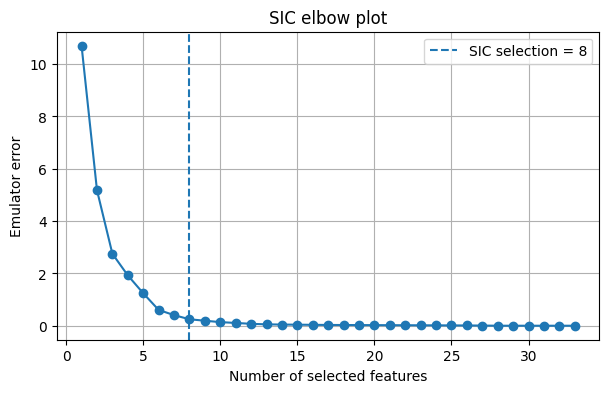

Selected (0-based) feature indices: [ 4  9 16 18 19 20 26 28]
Sensitivities: [0.0105 0.003  0.0009 0.0036 0.0007 0.9536 0.0239 0.0028]


In [ ]:
"""
Python port of the MATLAB feature-selection / SIC-method code.

Original MATLAB methods (by the user / Dr. Luca Martino for SICmethod):
    - featureSelection: greedy forward feature ranking based on a
      polynomial-fit emulator's prediction error.
    - SICmethod: Spectral Information Criterion (elbow method) used to
      automatically decide how many of the ranked features to keep.

IMPORTANT
---------
The original MATLAB code calls a helper `myinterpn(X, Y, Xq, 'polyfit')`
which is not included in the snippet you provided. That function is
reproduced here as an injected callable `interp_func` with the same
signature:

    out = interp_func(X_train, Y_train, X_query, method)

You need to supply your own implementation (e.g. wrapping
scipy.interpolate, a polynomial least-squares fit, an MLP, etc.) matching
whatever `myinterpn(..., 'polyfit')` did in your MATLAB codebase.

Indexing note: everything below has been converted from MATLAB's 1-based
indexing to Python's 0-based indexing. Selected feature indices returned
by `feature_selection` are therefore 0-based column indices into `Xt`.
"""

class FeatureSelectionEmulator:
    """
    Minimal container mirroring the MATLAB `obj` that featureSelection and
    SICmethod were methods of (obj.conf.kernel, obj.SICmethod(...)).
    """

    def __init__(self, kernel='none', interp_func=None):
        """
        Parameters
        ----------
        kernel : str
            Equivalent to `obj.conf.kernel`. If this equals
            'mahalanobissquaredexponential', the SIC elbow-detection step
            is skipped and *all* ranked features are kept (matching the
            MATLAB `if ~strcmp(...)` branch).
        interp_func : callable
            Your emulator/interpolation function, see module docstring.
        """
        self.conf = {'kernel': kernel}
        self.interp_func = interp_func

    # ------------------------------------------------------------------
    def feature_selection(self, Xt, Yt, alpha=1.0, plotting=False):
        """
        Ranks the input variables by importance based on the accuracy of
        a polynomial fitting, recursively adding more input variables.
        Once ranked, the Spectral Information Criterion (SIC) method is
        applied to automatically select the minimum number of features.

        Parameters
        ----------
        Xt : ndarray, shape (n_samples, n_features)
            Training inputs (each column is a candidate feature).
        Yt : ndarray, shape (n_samples, n_outputs)
            Training targets (e.g. samples of a transfer function).
        alpha : float, optional
            Exponent used in the error metric |Yt - out|**alpha.
            Default 1 (L1 norm), matching the MATLAB code.

        Returns
        -------
        features : ndarray of int
            0-based indices of the selected features, sorted ascending.
        w : ndarray of float
            Normalized sensitivity ("importance") of each selected
            feature, in the same order as `features`.
        """
        warnings.filterwarnings('ignore')

        Xt = np.asarray(Xt)
        Yt = np.asarray(Yt, dtype=float)
        if Yt.ndim == 1:
            Yt = Yt.reshape(-1, 1)

        n_samples, n_features = Xt.shape

        ii = list(range(n_features))        # remaining candidate features
        features = []                       # ranked feature indices (growing list)
        feat_err = np.full(n_features, np.nan)

        k = 0
        while len(ii) > 0:
            err = np.full(len(ii), np.nan)

            for i, cand in enumerate(ii):
                cols = features + [cand]
                X = Xt[:, cols].T  # shape (n_selected+1, n_samples), like MATLAB's X'

                out = self.interp_func(X, Yt, X, 'polyfit')
                out = np.asarray(out, dtype=float)

                aux = np.abs(Yt - out) ** alpha
                aux = np.mean(aux, axis=1)          # average across outputs (columns)
                aux[np.isinf(aux)] = 0

                if aux.size > 1:
                    valid = aux[aux < (1e4 ** alpha)]
                    err[i] = np.nanmean(valid) if valid.size else np.nan
                else:
                    err[i] = aux.item()

            j = int(np.nanargmin(err))
            feat_err[k] = err[j]
            features.append(ii[j])
            del ii[j]
            k += 1

        # --- Select number of features via the SIC elbow method ---------
        if self.conf.get('kernel') != 'mahalanobissquaredexponential':
            idfeat = self.sic_method(feat_err, 99)
            if plotting:
                self.plot_elbow(feat_err, idfeat)
        else:
            idfeat = len(features)

        # --- "No features" baseline: error vs. the average spectrum ------
        baseline = np.abs(Yt - np.mean(Yt, axis=1, keepdims=True)) ** alpha
        baseline[np.isinf(baseline)] = np.nan
        baseline = np.nanmean(baseline, axis=1)
        baseline[np.isinf(baseline)] = 0
        if baseline.size > 1:
            valid = baseline[baseline < (1e4 ** alpha)]
            baseline_err = np.nanmean(valid) if valid.size else np.nan
        else:
            baseline_err = baseline.item()

        feat_err_full = np.concatenate(([baseline_err], feat_err))

        # --- Sensitivity: normalized drop in error when adding a feature -
        w_full = np.abs(np.diff(feat_err_full))
        w_full = w_full / np.sum(w_full)
        w_full = np.nan_to_num(w_full)

        # --- Keep the first `idfeat` (already ranked) features, sort them
        features = np.array(features)
        selected = features[:idfeat]
        order = np.argsort(selected)
        features_sorted = selected[order]
        w = w_full[:idfeat][order]

        return features_sorted, w

    # ------------------------------------------------------------------
    def sic_method(self, V, CI=95, N=100_000):
        """
        Spectral Information Criterion (SIC) method.
        Applies the SIC method for automatic feature selection, returning
        the number of (already ranked) features to retain.

        Parameters
        ----------
        V : array_like
            Errors associated with each ranked feature (as produced by
            `feature_selection`'s internal ranking loop).
        CI : float, optional
            Confidence interval, in percent, clipped to [50, 100].
            Default 95.
        N : int, optional
            Number of Monte Carlo runs, minimum 1000. Default 1e5.

        Returns
        -------
        idfeat : int
            Number of features to keep (a count, usable directly as
            `features[:idfeat]`).

        Notes
        -----
        Method by Dr. Luca Martino (Universidad Rey Juan Carlos).
        """
        V = np.asarray(V, dtype=float)
        L = V.size

        CI = CI / 100.0
        CI = max(0.5, min(1.0, CI))
        N = max(1000, int(N))

        # eta_max: largest average decrease in error per added feature
        idx = np.arange(1, L)                    # 1, 2, ..., L-1
        aux_amount = (V[0] - V[1:]) / idx
        eta_max = np.max(aux_amount)

        # Monte Carlo simulation
        eta_rand = eta_max * np.random.rand(N, 1)         # (N, 1)
        offsets = np.arange(L)                            # 0, ..., L-1
        eta = V[None, :] + eta_rand * offsets[None, :]     # (N, L)

        is_min = eta == eta.min(axis=1, keepdims=True)
        pos = np.argmax(is_min, axis=1)                    # first True per row (0-based)

        # PMF of elbow position
        wn = np.array([np.sum(pos == p) for p in range(L)], dtype=float)
        wn /= wn.sum()

        cum_fun = np.cumsum(wn)
        idx0 = int(np.argmax(cum_fun > CI))    # first index exceeding CI
        idfeat = idx0 + 1                      # convert to a 1-based count

        return idfeat
    
    # ------------------------------------------------------------------
    def plot_elbow(self, feat_err, idfeat):
        print(f"Error at SIC selection: {feat_err[idfeat-1]}")
        plt.figure(figsize=(7,4))

        plt.plot(np.arange(1,len(feat_err)+1), feat_err, marker='o')

        plt.axvline(idfeat, linestyle='--', label=f'SIC selection = {idfeat}')

        plt.xlabel("Number of selected features")
        plt.ylabel("Emulator error")
        plt.title("SIC elbow plot")
        plt.legend()
        plt.grid(True)

        plt.show()


def quadratic_polyfit_interp(X_train, Y_train, X_query, method):

    # X_train is (n_features, n_samples)
    X_train = X_train.T
    X_query = X_query.T

    poly = PolynomialFeatures(degree=2, include_bias=True)

    X_train_poly = poly.fit_transform(X_train)
    X_query_poly = poly.transform(X_query)

    model = LinearRegression()
    model.fit(X_train_poly, Y_train)

    return model.predict(X_query_poly)

emu = FeatureSelectionEmulator(kernel='none', interp_func=quadratic_polyfit_interp)
features, w = emu.feature_selection(X_tr, Y_tr.reshape(Y_tr.shape[0], -1), plotting=True)

print("Selected (0-based) feature indices:", features)
print("Sensitivities:", w)

In [107]:
features = [4, 9, 16, 18, 19, 20, 26, 28]
w = [0.0105, 0.003, 0.0009, 0.0036, 0.0007, 0.9536, 0.0239, 0.0028]

for i, feat_idx in enumerate(features):
    print(f"{i+1}) Selected feature: {feature_names[feat_idx]} with sensitivity {w[i]:.4f}")

1) Selected feature: AE with sensitivity 0.0105
2) Selected feature: cos_SZA with sensitivity 0.0030
3) Selected feature: O3_airmass with sensitivity 0.0009
4) Selected feature: CWV_sec_SZA with sensitivity 0.0036
5) Selected feature: log_AOD with sensitivity 0.0007
6) Selected feature: AOD_sec_SZA with sensitivity 0.9536
7) Selected feature: AOD_scattering_OD with sensitivity 0.0239
8) Selected feature: SSA_g with sensitivity 0.0028


In [108]:
# select training data based on resulting features
X_tr_sel = X_tr_expanded[:, features]
X_val_sel = X_val_expanded[:, features]
X_test_sel = X_test_expanded[:, features]

print(f"Shape of X_tr after selection: {X_tr_sel.shape}")
print(f"Shape of X_val after selection: {X_val_sel.shape}")
print(f"Shape of X_test after selection: {X_test_sel.shape}")

Shape of X_tr after selection: (400, 8)
Shape of X_val after selection: (50, 8)
Shape of X_test after selection: (50, 8)


#### Neural Network Training

In [67]:
# quick model test
model = nn_models.EmulatorSet5(encoder_type="single").to(device)
model.eval()

# dummy input: (batch_size, 9)
X_tr_tensor = torch.randn(400, 8, dtype=torch.float32).to(device)
print("Input shape:", X_tr_tensor.shape)

with torch.no_grad():
    y_pred = model(X_tr_tensor)

# y is a tensor of shape (N, 6, 4205)
print("Output shape:", y_pred.shape)

info_summary(model, input_size=(1, 8))

Input shape: torch.Size([400, 8])
Output shape: torch.Size([400, 6, 4205])


Layer (type:depth-idx)                        Output Shape              Param #
EmulatorSet5                                  [1, 6, 4205]              --
├─Encoder5: 1-1                               [1, 128]                  --
│    └─Sequential: 2-1                        [1, 128]                  --
│    │    └─Linear: 3-1                       [1, 64]                   576
│    │    └─SiLU: 3-2                         [1, 64]                   --
│    │    └─Linear: 3-3                       [1, 128]                  8,320
│    │    └─SiLU: 3-4                         [1, 128]                  --
│    │    └─Linear: 3-5                       [1, 128]                  16,512
│    │    └─SiLU: 3-6                         [1, 128]                  --
├─ModuleList: 1-2                             --                        --
│    └─SpectralDecoder5: 2-2                  [1, 4205]                 --
│    │    └─Linear: 3-7                       [1, 512]                  66,048
│    │  

In [109]:
# ==================== EXPERIMENT GRID ====================
ARCHITECTURES = {
    "EmulatorSet5": nn_models.EmulatorSet5,
}

ENCODER_VERSIONS = [
    "single",
    # "multi",
]

SCALE_TYPES = [
    "minmax",
    # "standard",
]

# which model families use the full dataset vs. the reduced one
FULL_DS_MODELS    = {"EmulatorSet1", "EmulatorSet5"}
REDUCED_DS_MODELS = {"EmulatorSet2", "EmulatorSet3", "EmulatorSet4"}

BATCH_SIZE = 4
N_EPOCHS = 100
PATIENCE = 25

In [110]:
def create_datasets(X_tr, X_val, Y_tr, Y_val, X_test, Y_test, verbose=True):
    train_ds = nn_dataset.MyDataset(X_tr, Y_tr)
    val_ds = nn_dataset.MyDataset(X_val, Y_val)
    test_ds = nn_dataset.MyDataset(X_test, Y_test)

    if verbose:
        print("Train dataset length:", len(train_ds))
        print("Val dataset length:", len(val_ds))
        print("Test dataset length:", len(test_ds))

        # get item check
        x, y = train_ds.__getitem__(0)
        print("Input shape:", x.shape)
        print("Output shape:", y.shape)
        print()

    return train_ds, val_ds, test_ds


def prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test, n_pca_components=10):
    config = {
        "x_scalers":               {},
        "y_scalers":               {},
        "y_scalers_reduced":       {},
        "pca_lists":               {},
        "train_ds_scaled":         {},
        "val_ds_scaled":           {},
        "test_ds_scaled":          {},
        "train_ds_reduced_scaled": {},
        "val_ds_reduced_scaled":   {},
        "test_ds_reduced_scaled":  {},
    }

    # PCA is fit on raw outputs — independent of scale type, so compute once
    pca_list, Y_tr_reduced, Y_val_reduced = utils.apply_pca(Y_tr, Y_val, n_components=n_pca_components)
    Y_test_reduced = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, n_pca_components))
    for i in range(globals.N_FUNCTIONS):
        Y_test_reduced[:, i, :] = pca_list[i].transform(Y_test[:, i, :])

    for scale_type in SCALE_TYPES:
        print(f"\n── Preparing [{scale_type}] ──────────────────────────────")

        # --- inputs ---
        x_scaler, X_tr_scaled, X_val_scaled = utils.scale_input_data(
            X_tr, X_val, scale_type=scale_type
        )
        X_test_scaled = x_scaler.transform(X_test)

        # --- full outputs ---
        y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(
            Y_tr, Y_val, scale_type=scale_type
        )
        Y_test_scaled = np.zeros_like(Y_test)
        for i in range(globals.N_FUNCTIONS):
            Y_test_scaled[:, i, :] = y_scalers[i].transform(Y_test[:, i, :])

        # --- reduced outputs ---
        y_scalers_reduced, Y_tr_reduced_scaled, Y_val_reduced_scaled = utils.scale_output_data(
            Y_tr_reduced, Y_val_reduced, scale_type=scale_type
        )
        Y_test_reduced_scaled = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, n_pca_components))
        for i in range(globals.N_FUNCTIONS):
            Y_test_reduced_scaled[:, i, :] = y_scalers_reduced[i].transform(Y_test_reduced[:, i, :])

        # --- datasets ---
        train_ds_scaled, val_ds_scaled, test_ds_scaled = create_datasets(
            X_tr_scaled, X_val_scaled, Y_tr_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled
        )
        train_ds_reduced_scaled, val_ds_reduced_scaled, test_ds_reduced_scaled = create_datasets(
            X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled, Y_val_reduced_scaled,
            X_test_scaled, Y_test_reduced_scaled
        )

        # --- store everything under the scale_type key ---
        config["x_scalers"][scale_type]               = x_scaler
        config["y_scalers"][scale_type]               = y_scalers
        config["y_scalers_reduced"][scale_type]       = y_scalers_reduced
        config["pca_lists"][scale_type]               = pca_list        # same for both
        config["train_ds_scaled"][scale_type]         = train_ds_scaled
        config["val_ds_scaled"][scale_type]           = val_ds_scaled
        config["test_ds_scaled"][scale_type]          = test_ds_scaled
        config["train_ds_reduced_scaled"][scale_type] = train_ds_reduced_scaled
        config["val_ds_reduced_scaled"][scale_type]   = val_ds_reduced_scaled
        config["test_ds_reduced_scaled"][scale_type]  = test_ds_reduced_scaled

    # training hyperparameters
    config["batch_size"] = BATCH_SIZE
    config["n_epochs"]   = N_EPOCHS
    config["patience"]   = PATIENCE

    return config


# ==================== DATASET / SCALER ROUTER ====================
def get_loaders_and_scalers(model_name, scale_type, config):
    """Return (train_dl, val_dl, y_scalers) for a given experiment."""
    if model_name in FULL_DS_MODELS:
        train_ds = config["train_ds_scaled"][scale_type]
        val_ds   = config["val_ds_scaled"][scale_type]
        y_scalers = config["y_scalers"][scale_type]
        pca_list = None
    else:
        train_ds = config["train_ds_reduced_scaled"][scale_type]
        val_ds   = config["val_ds_reduced_scaled"][scale_type]
        y_scalers = config["y_scalers_reduced"][scale_type]
        pca_list = config["pca_lists"][scale_type]

    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=config["batch_size"], shuffle=False)
    return train_ds, val_ds, train_dl, val_dl, y_scalers, pca_list


def calculate_metrics(y_pred, Y_batch, wavelengths, y_scalers, pca_list):
    is_scaled  = y_scalers is not None
    is_reduced = pca_list  is not None

    if is_scaled or is_reduced:
        # prepare tensors to hold the restored predictions and targets in original space
        y_pred_og_shape = torch.zeros((y_pred.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred.device)
        y_true_og_shape = torch.zeros((Y_batch.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=Y_batch.device)

        # inverse transform the scaling and PCA to get back to original space if needed
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred[:, i, :].cpu().detach().numpy()
            y_true_restored = Y_batch[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
                y_true_restored = y_scalers[i].inverse_transform(y_true_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
                y_true_restored = pca_list[i].inverse_transform(y_true_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_og_shape.device)
            y_true_og_shape[:, i, :] = torch.from_numpy(y_true_restored).to(y_true_og_shape.device)

        batch_train_mre_unscaled = utils.mre_score(y_true_og_shape.cpu().detach().numpy(), y_pred_og_shape.cpu().detach().numpy(), wavelengths)
        batch_train_mae_unscaled = utils.mae_score(y_true_og_shape.cpu().detach().numpy(), y_pred_og_shape.cpu().detach().numpy(), wavelengths)
    else:
        batch_train_mre_unscaled = utils.mre_score(Y_batch.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), wavelengths)
        batch_train_mae_unscaled = utils.mae_score(Y_batch.cpu().detach().numpy(), y_pred.cpu().detach().numpy(), wavelengths)

    return batch_train_mre_unscaled, batch_train_mae_unscaled


# ==================== SINGLE EXPERIMENT ====================
def run_experiment(model_name, encoder_version, scale_type, config, device, wavelengths):
    dataset_size = int(re.search(r'\d+', Path(globals.CURRENT_TRAIN_FILE).stem).group())
    exp_id = f"{model_name}_{encoder_version}_{scale_type}_{dataset_size}"
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {exp_id}")
    print(f"{'='*60}")

    # --- build model ---
    ModelClass = ARCHITECTURES[model_name]
    model = ModelClass(encoder_type=encoder_version).to(device)

    # --- data ---
    train_ds, val_ds, train_dl, val_dl, y_scalers, pca_list = get_loaders_and_scalers(
        model_name, scale_type, config
    )

    # --- optimiser / loss / scheduler ---
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.L1Loss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.2, patience=5
    )

    # --- early stopping state ---
    n_epochs        = config.get("n_epochs", 100)
    patience        = config.get("patience", 25)
    best_val_mre    = float("inf")
    patience_counter = 0
    best_model_wts  = copy.deepcopy(model.state_dict())
    history         = defaultdict(list)

    start_time = time.time()

    for epoch in range(n_epochs):
        # ---------- TRAIN ----------
        model.train()
        epoch_train_loss = epoch_train_mre = epoch_train_mae = 0.0
        # accumulate preds and targets to compute metrics once at the end of the loop to avoid aggregation artifacts
        all_preds   = []
        all_targets = []

        for X_batch, Y_batch in tqdm(train_dl, desc=f"[{exp_id}] E{epoch+1} Train", leave=False):
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, Y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * X_batch.size(0)
            all_preds.append(y_pred.detach().cpu())
            all_targets.append(Y_batch.cpu())

        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        epoch_train_mre, epoch_train_mae = calculate_metrics(all_preds, all_targets, wavelengths, y_scalers, pca_list)
        epoch_train_loss /= len(train_ds)

        # ---------- VALIDATE ----------
        model.eval()
        epoch_val_loss = epoch_val_mre = epoch_val_mae = 0.0
        all_preds   = []
        all_targets = []

        with torch.no_grad():
            for X_batch, Y_batch in tqdm(val_dl, desc=f"[{exp_id}] E{epoch+1} Val", leave=False):
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                y_pred = model(X_batch)
                loss   = criterion(y_pred, Y_batch)

                epoch_val_loss += loss.item() * X_batch.size(0)
                all_preds.append(y_pred.cpu())
                all_targets.append(Y_batch.cpu())

        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        epoch_val_mre, epoch_val_mae = calculate_metrics(all_preds, all_targets, wavelengths, y_scalers, pca_list)
        epoch_val_loss /= len(val_ds)

        scheduler.step(epoch_val_mre)

        # record
        history["train_loss"].append(epoch_train_loss)
        history["train_mre"].append(epoch_train_mre)
        history["train_mae"].append(epoch_train_mae)
        history["val_loss"].append(epoch_val_loss)
        history["val_mre"].append(epoch_val_mre)
        history["val_mae"].append(epoch_val_mae)

        print(
            f"  E{epoch+1:03d} | "
            f"train loss {epoch_train_loss:.5f}  mre {epoch_train_mre:.5f}  mae {epoch_train_mae:.5f} | "
            f"val loss {epoch_val_loss:.5f}  mre {epoch_val_mre:.5f}  mae {epoch_val_mae:.5f}"
        )

        # ---------- EARLY STOPPING ----------
        if epoch_val_mre < best_val_mre:
            best_val_mre   = epoch_val_mre
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("  --> best val MRE — weights saved")
        else:
            patience_counter += 1
            print(f"  --> no improvement ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print("  !!! early stopping !!!")
                break

    elapsed = time.time() - start_time

    # reload best weights
    model.load_state_dict(best_model_wts)

    # persist model
    os.makedirs("nn_saves", exist_ok=True)
    torch.save(model.state_dict(), f"nn_saves/model_saves/{exp_id}.pth")

    # save history
    with open(f"nn_saves/model_saves/{exp_id}_history.pkl", "wb") as f:
        pickle.dump(history, f)

    # build result row
    idx_best = int(np.argmin(history["val_mre"]))
    result = {
        "experiment_id":  exp_id,
        "model":          model_name,
        "encoder":        encoder_version,
        "scale_type":     scale_type,
        "dataset_size":   dataset_size,
        "fit_time":       elapsed,
        "best_epoch":     idx_best + 1,
        "best_train_loss": history["train_loss"][idx_best],
        "best_val_loss":   history["val_loss"][idx_best],
        "best_train_mre":  history["train_mre"][idx_best],
        "best_val_mre":    history["val_mre"][idx_best],
        "best_train_mae":  history["train_mae"][idx_best],
        "best_val_mae":    history["val_mae"][idx_best],
    }
    return model, history, result


# ==================== FULL EXPERIMENT LOOP ====================
def run_all_experiments(config, device, wavelengths):
    results_path = Path("nn_saves/validation_results/nn_val_results.csv")
    all_results  = []

    grid = list(itertools.product(ARCHITECTURES.keys(), ENCODER_VERSIONS, SCALE_TYPES))
    print(f"Total experiments to run: {len(grid)}")

    for model_name, encoder_version, scale_type in grid:
        try:
            model, history, result = run_experiment(
                model_name, encoder_version, scale_type,
                config, device, wavelengths
            )
            all_results.append(result)

            # append to CSV after every experiment so a crash doesn't lose data
            row_df = pd.DataFrame([result])
            row_df.to_csv(
                results_path,
                mode="a",
                header=not results_path.exists(),
                index=False,
            )
            print(f"  Saved results for {result['experiment_id']}\n")

        except Exception as e:
            print(f"  [ERROR] {model_name}__{encoder_version}__{scale_type} failed: {e}")
            continue

    summary = pd.DataFrame(all_results).sort_values("best_val_mre")
    print("\n===== EXPERIMENT SUMMARY (sorted by val MRE) =====")
    print(summary[["experiment_id", "best_val_mre", "best_val_mae", "best_epoch", "fit_time"]].to_string(index=False))
    return summary, model, history

In [ ]:
config = prepare_all_experiments(X_tr_sel, X_val_sel, X_test_sel, Y_tr, Y_val, Y_test)

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------


── Preparing [minmax] ──────────────────────────────
---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

---------- Scaling ou

In [ ]:
# ============================== !!CRITICAL CELL!! ==============================

summary, last_model, last_history = run_all_experiments(config, device, wavelengths)

Total experiments to run: 1

  EXPERIMENT: EmulatorSet5_single_minmax_500


  E001 | train loss 0.20664  mre 0.22284  mae 32.51112 | val loss 0.16571  mre 0.20612  mae 26.83193
  --> best val MRE — weights saved


  E002 | train loss 0.11247  mre 0.12281  mae 24.65103 | val loss 0.07475  mre 0.08189  mae 16.20991
  --> best val MRE — weights saved


  E003 | train loss 0.05729  mre 0.05685  mae 12.08927 | val loss 0.04859  mre 0.05247  mae 8.23918
  --> best val MRE — weights saved


  E004 | train loss 0.04308  mre 0.04249  mae 7.25840 | val loss 0.03542  mre 0.03499  mae 5.56408
  --> best val MRE — weights saved


...

  E096 | train loss 0.01042  mre 0.00828  mae 0.88658 | val loss 0.01121  mre 0.00942  mae 1.02042
  --> no improvement (17/25)


  E097 | train loss 0.01042  mre 0.00828  mae 0.88666 | val loss 0.01121  mre 0.00942  mae 1.02030
  --> no improvement (18/25)


  E098 | train loss 0.01042  mre 0.00828  mae 0.88627 | val loss 0.01121  mre 0.00942  mae 1.02037
  --> no improvement (19/25)


  E099 | train loss 0.01042  mre 0.00828  mae 0.88629 | val loss 0.01121  mre 0.00942  mae 1.02035
  --> no improvement (20/25)


  E100 | train loss 0.01042  mre 0.00828  mae 0.88630 | val loss 0.01121  mre 0.00942  mae 1.02033
  --> no improvement (21/25)
  Saved results for EmulatorSet5_single_minmax_500


===== EXPERIMENT SUMMARY (sorted by val MRE) =====
                 experiment_id  best_val_mre  best_val_mae  best_epoch   fit_time
EmulatorSet5_single_minmax_500      0.009397      1.023541          79 164.835426


In [113]:
summary

,experiment_id,model,encoder,scale_type,dataset_size,fit_time,best_epoch,best_train_loss,best_val_loss,best_train_mre,best_val_mre,best_train_mae,best_val_mae
0,EmulatorSet5_single_minmax_500,EmulatorSet5,single,minmax,500,164.835426,79,0.010502,0.011224,0.008364,0.009397,0.90192,1.023541
